In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv('cybersecurity.csv')


In [27]:
df.shape


(10000, 13)

In [28]:
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [29]:
df.columns

Index(['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
       'bytes_sent', 'bytes_received', 'user_agent', 'url',
       'is_internal_traffic', 'label', 'attack_type'],
      dtype='str')

In [30]:
df['attack_type'].value_counts().head(5) # Ataques mas relevantes

attack_type
benign           9600
brute-force       108
port-scan          81
sql-injection      64
xss                34
Name: count, dtype: int64

In [31]:
df[df['attack_type'] != 'benign']['attack_type'].value_counts().head(5) # Ataques mas relevantes sin contar los benignos

attack_type
brute-force            108
port-scan               81
sql-injection           64
xss                     34
credential-stuffing     28
Name: count, dtype: int64

In [32]:
ataques = df[df['attack_type'] != 'benign'] # Filtramos los ataques que no son benignos


In [33]:
top_ips_ataques = ataques['src_ip'].value_counts().head(10)# Obtenemos las 10 IPs de origen más incidentes en ataques
print("TOP 10 IPs DE ORIGEN MÁS INCIDENTES EN ATAQUES:")
print(top_ips_ataques)
print("\n" + "="*60 + "\n")
# Para cada una de esas IPs, ver qué tipo de ataque realizaron
print("DETALLE DE ATAQUES POR IP:")
for ip in top_ips_ataques.index:
    print(f"\nIP: {ip} (Total: {top_ips_ataques[ip]} ataques)")
    print(ataques[ataques['src_ip'] == ip]['attack_type'].value_counts())

TOP 10 IPs DE ORIGEN MÁS INCIDENTES EN ATAQUES:
src_ip
150.200.236.198    1
200.37.141.199     1
24.167.28.156      1
187.217.212.36     1
78.5.49.201        1
10.16.90.143       1
77.186.223.52      1
170.239.137.240    1
32.160.168.214     1
22.212.188.47      1
Name: count, dtype: int64


DETALLE DE ATAQUES POR IP:

IP: 150.200.236.198 (Total: 1 ataques)
attack_type
port-scan    1
Name: count, dtype: int64

IP: 200.37.141.199 (Total: 1 ataques)
attack_type
port-scan    1
Name: count, dtype: int64

IP: 24.167.28.156 (Total: 1 ataques)
attack_type
sql-injection    1
Name: count, dtype: int64

IP: 187.217.212.36 (Total: 1 ataques)
attack_type
port-scan    1
Name: count, dtype: int64

IP: 78.5.49.201 (Total: 1 ataques)
attack_type
c2    1
Name: count, dtype: int64

IP: 10.16.90.143 (Total: 1 ataques)
attack_type
credential-stuffing    1
Name: count, dtype: int64

IP: 77.186.223.52 (Total: 1 ataques)
attack_type
brute-force    1
Name: count, dtype: int64

IP: 170.239.137.240 (Total: 1 at

#Horario de incidencia de ataques

In [34]:
df['timestamp'] = pd.to_datetime(df['timestamp'])  #

In [35]:
ataques = df[df['attack_type'] != 'benign'].copy()# Creamos una copia del DataFrame para trabajar solo con los ataques


In [36]:
print(ataques)

               timestamp           src_ip           dst_ip  src_port  \
11   2025-10-01 02:31:52  150.200.236.198   87.119.113.169        80   
27   2025-10-01 06:36:26   200.37.141.199   236.32.118.228     19269   
177  2025-10-02 19:37:13    24.167.28.156   161.58.210.251       443   
189  2025-10-02 22:13:10   187.217.212.36     94.80.191.10     54434   
235  2025-10-03 12:22:56      78.5.49.201   176.177.97.102     48533   
...                  ...              ...              ...       ...   
9879 2025-12-28 22:04:13   120.199.220.10    211.124.48.88      5536   
9934 2025-12-29 09:01:52  226.172.240.219   209.137.247.75     43014   
9956 2025-12-29 13:25:37     197.1.26.228  153.115.232.126        22   
9962 2025-12-29 14:55:02   114.51.218.213    118.11.209.91     22822   
9997 2025-12-29 23:11:46    211.68.159.72   149.12.197.127     18395   

      dst_port protocol  bytes_sent  bytes_received  \
11         213      TCP        3150           11715   
27           5      UDP  

In [37]:
ataques['hora'] = ataques['timestamp'].dt.hour

In [38]:
print(ataques['hora'])

11       2
27       6
177     19
189     22
235     12
        ..
9879    22
9934     9
9956    13
9962    14
9997    23
Name: hora, Length: 400, dtype: int32


In [39]:
ataques_por_hora = ataques['hora'].value_counts().sort_index()

In [40]:
print(ataques_por_hora)

hora
0     17
1     22
2     17
3     15
4     11
5     15
6     20
7     12
8     15
9     19
10    19
11    14
12    16
13    25
14    22
15    18
16    16
17    18
18    10
19    15
20    17
21    12
22    18
23    17
Name: count, dtype: int64


In [41]:
ataques_por_hora_tipo = ataques.groupby(['hora', 'attack_type']).size().reset_index(name='cantidad').head(10)

In [42]:
ataques_por_hora_tipo = ataques_por_hora_tipo.sort_values(['hora', 'cantidad'], ascending=[True, False]).head(10)# Obtenemos las 10 horas con más ataques, ordenados por hora y cantidad

In [43]:
for _, row in ataques_por_hora_tipo.iterrows():# Iteramos por cada fila del DataFrame para imprimir el detalle de ataques por hora y tipo
    print(f"{row['hora']:02d}:00:01   tipo de ataque: {row['attack_type']:15}   cantidad: {row['cantidad']}")

00:00:01   tipo de ataque: brute-force       cantidad: 4
00:00:01   tipo de ataque: credential-stuffing   cantidad: 4
00:00:01   tipo de ataque: c2                cantidad: 2
00:00:01   tipo de ataque: ddos              cantidad: 2
00:00:01   tipo de ataque: xss               cantidad: 2
00:00:01   tipo de ataque: exploit-attempt   cantidad: 1
00:00:01   tipo de ataque: port-scan         cantidad: 1
00:00:01   tipo de ataque: sql-injection     cantidad: 1
01:00:01   tipo de ataque: brute-force       cantidad: 6
01:00:01   tipo de ataque: c2                cantidad: 2


#CLASIFICACION POR TIPO DE ATAQUE EXCLUYENDO LOS 

In [44]:
ataques_por_hora_tipo['etiqueta'] = ataques_por_hora_tipo['hora'].astype(str) + ':00 - ' + ataques_por_hora_tipo['attack_type']

In [45]:
top_10 = ataques_por_hora_tipo.sort_values(['hora', 'cantidad'], ascending=[True, False]).head(10)

<Axes: title={'center': 'Top 10 ataques por hora y tipo'}, xlabel='etiqueta'>

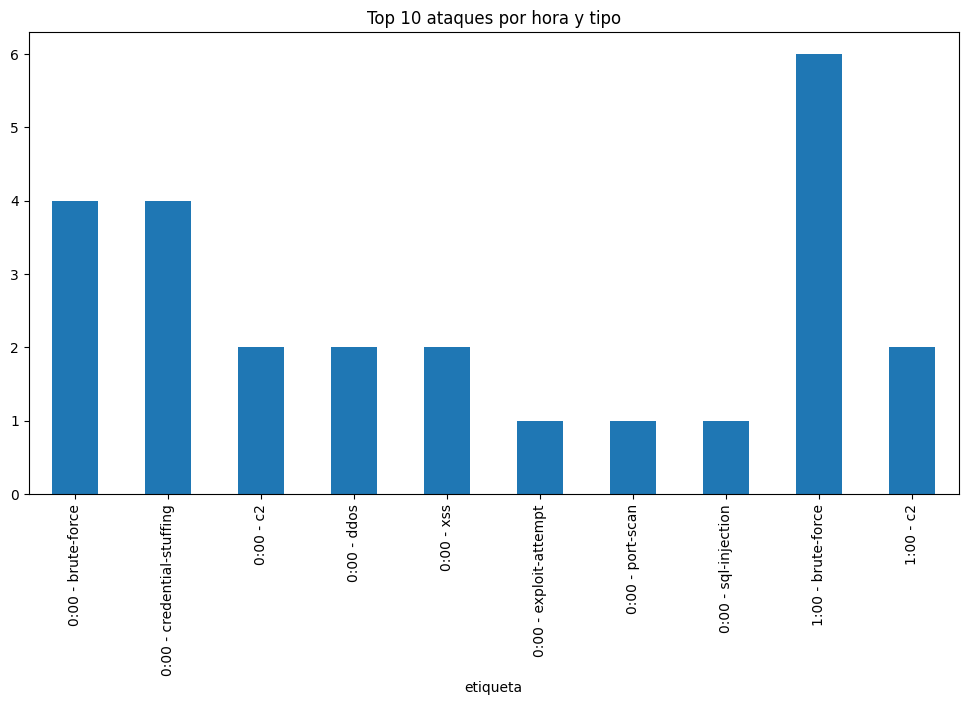

In [46]:
top_10.set_index('etiqueta')['cantidad'].plot(kind='bar', figsize=(12,6), title='Top 10 ataques por hora y tipo')

In [47]:
top_20 = df[df['attack_type'] != 'benign'].groupby(['attack_type', 'src_ip']).size().reset_index(name='cantidad')

In [48]:
top_20 = top_20.sort_values('cantidad', ascending=False).head(20)

In [49]:
top_20['etiqueta'] = top_20['attack_type'] + ' - ' + top_20['src_ip']


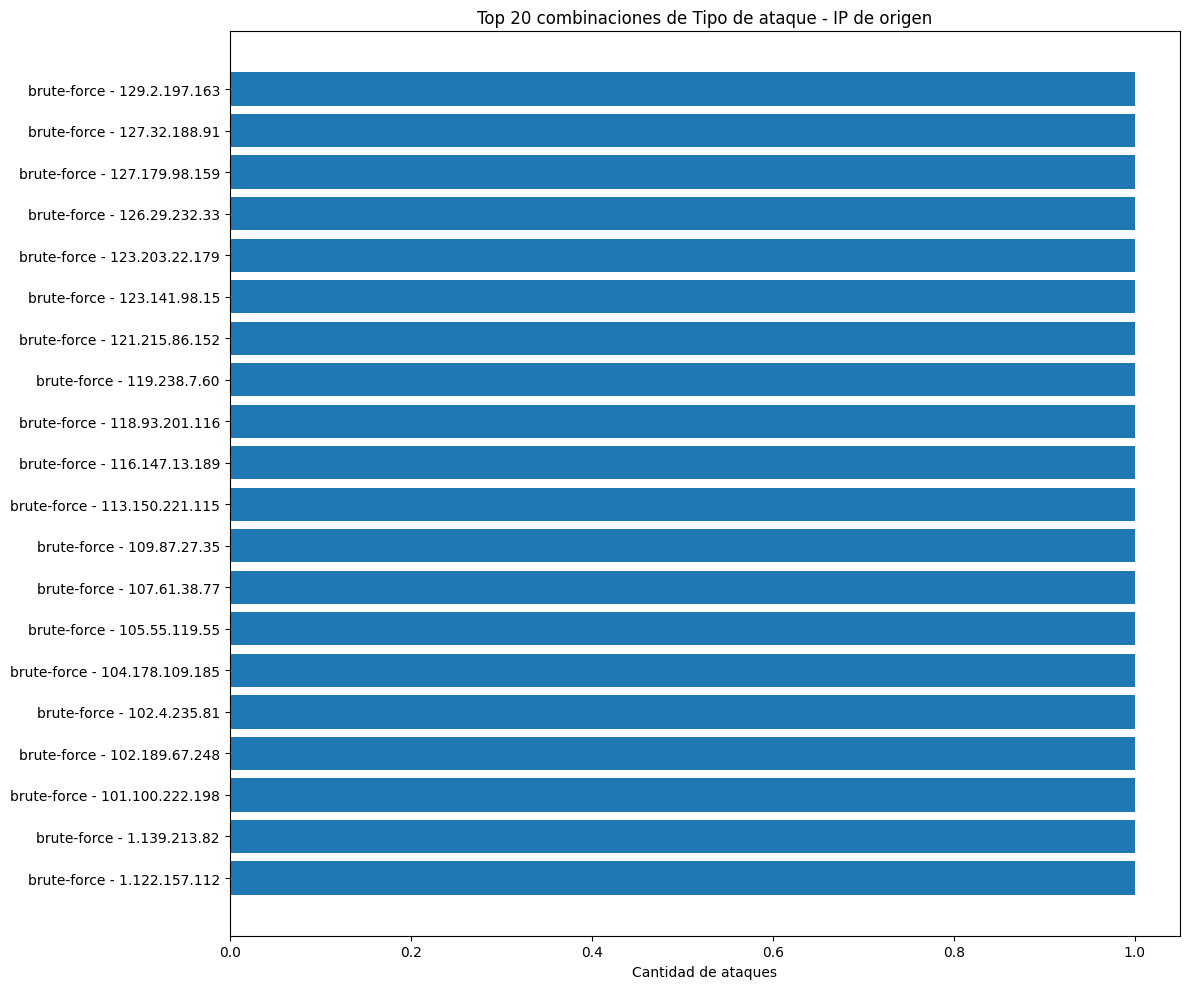

In [50]:
plt.figure(figsize=(12, 10))
plt.barh(range(len(top_20)), top_20['cantidad'])
plt.yticks(range(len(top_20)), top_20['etiqueta'])
plt.xlabel('Cantidad de ataques')
plt.title('Top 20 combinaciones de Tipo de ataque - IP de origen')
plt.tight_layout()
plt.show()

In [51]:
import seaborn as sns

In [52]:
ataques['hora'] = ataques['timestamp'].dt.hour
ataques['dia'] = ataques['timestamp'].dt.day
ataques['mes'] = ataques['timestamp'].dt.month

In [53]:
columnas_numericas = ['src_port', 'dst_port', 'bytes_sent', 'bytes_received', 
                      'hora', 'dia', 'mes']

In [54]:
corr = ataques[columnas_numericas].corr()

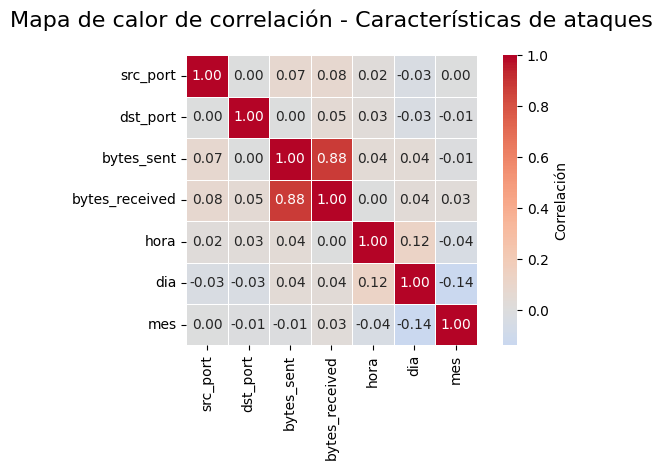

In [55]:
sns.heatmap(corr, 
            annot=True,           # Mostrar valores en las celdas
            fmt='.2f',            # Formato de 2 decimales
            cmap='coolwarm',      # Mapa de colores
            center=0,             # Centro en 0
            square=True,           # Celdas cuadradas
            linewidths=0.5,        # Líneas entre celdas
            cbar_kws={'label': 'Correlación'})

plt.title('Mapa de calor de correlación - Características de ataques', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

#Correlación entre bytes_sent y bytes_received (Tráfico de red)

In [56]:
puertos_ataque = pd.crosstab(df['dst_port'], df['attack_type'])# Creamos una tabla cruzada para contar la cantidad de ataques por puerto de destino y tipo de ataque

In [57]:
top_puertos_ataques = df[df['attack_type'] != 'benign']['dst_port'].value_counts().head(20).index
puertos_top = puertos_ataque.loc[top_puertos_ataques]

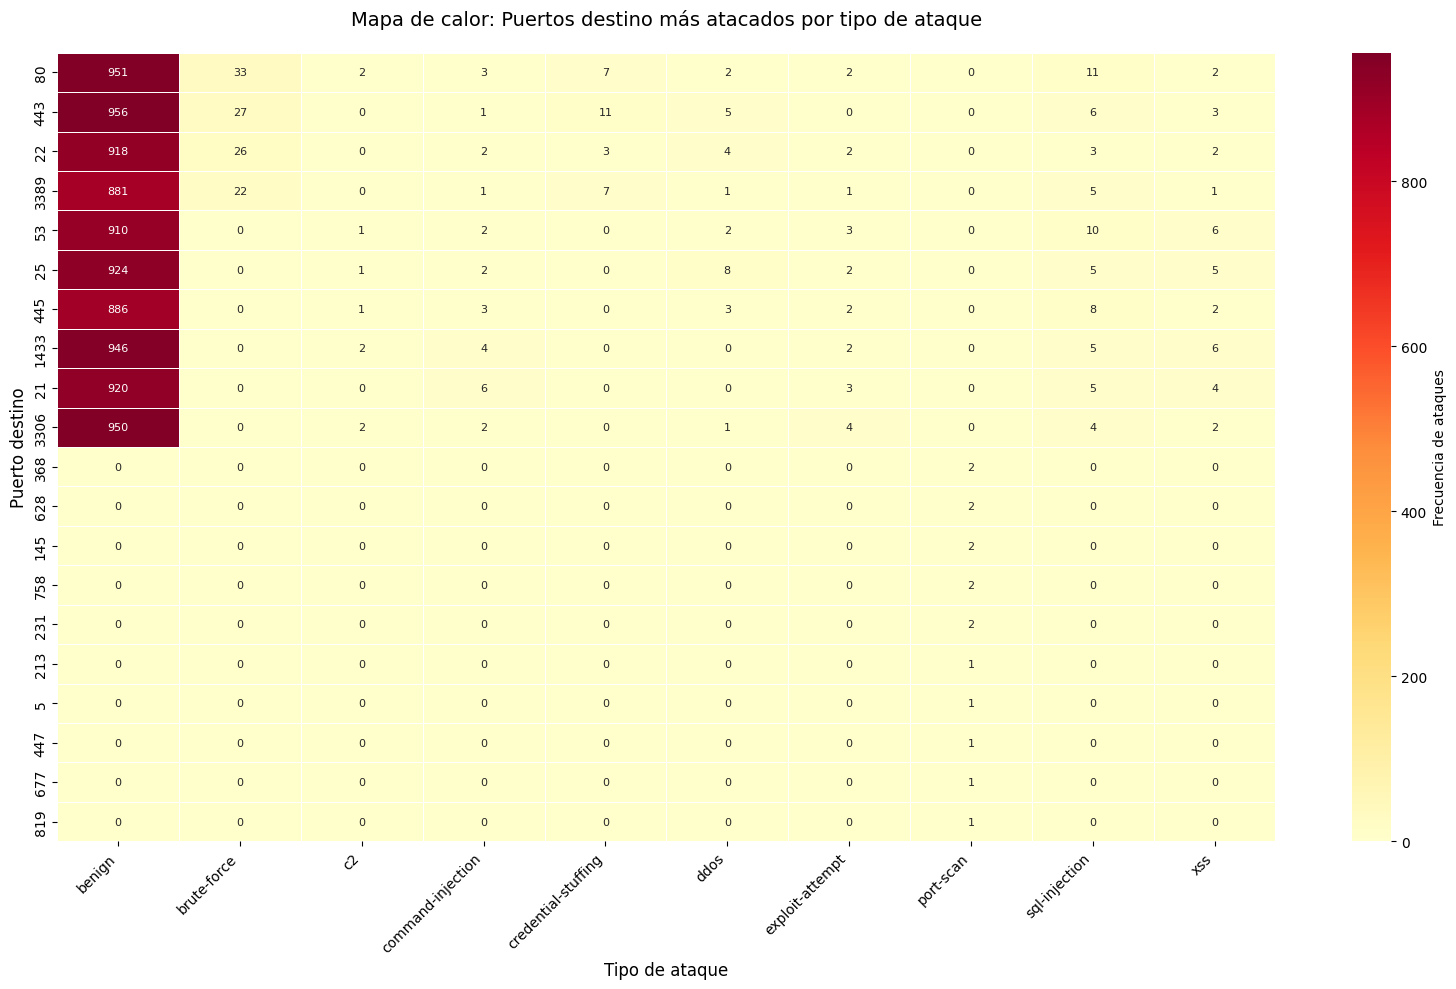

In [58]:
plt.figure(figsize=(16, 10))
sns.heatmap(puertos_top, 
            annot=True,           # Mostrar números
            fmt='d',               # Formato entero
            cmap='YlOrRd',         # Amarillo a Rojo (intensidad)
            linewidths=0.5, 
            cbar_kws={'label': 'Frecuencia de ataques'},
            annot_kws={'size': 8})

plt.xlabel('Tipo de ataque', fontsize=12)
plt.ylabel('Puerto destino', fontsize=12)
plt.title('Mapa de calor: Puertos destino más atacados por tipo de ataque', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Correlacion 

In [59]:
df.columns


Index(['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
       'bytes_sent', 'bytes_received', 'user_agent', 'url',
       'is_internal_traffic', 'label', 'attack_type'],
      dtype='str')

In [60]:
corr = df[['bytes_sent', 'bytes_received', 'src_port', 'dst_port', 'is_internal_traffic']].corr()

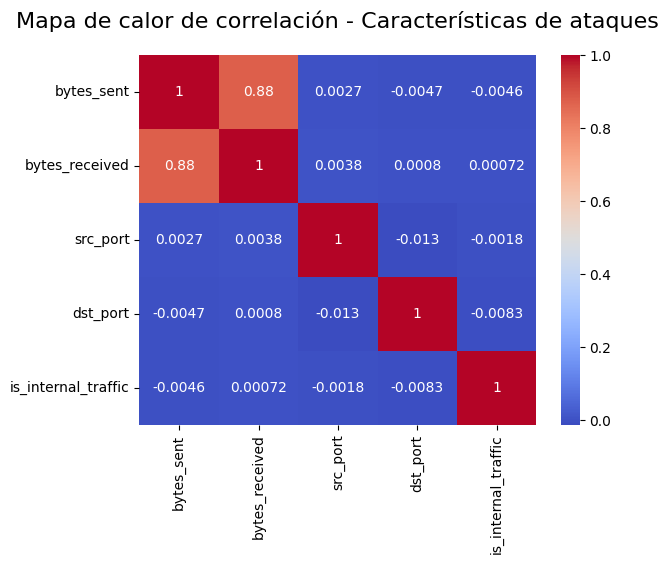

In [61]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación - Características de ataques', fontsize=16, pad=20)
plt.show()


In [62]:
df.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

In [63]:
df.describe()


,timestamp,src_port,dst_port,bytes_sent,bytes_received,label
count,10000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,2025-11-15 06:38:17.723800,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
min,2025-10-01 00:12:54,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,2025-10-24 05:26:16.750000,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,2025-11-15 16:26:25,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,2025-12-07 06:18:23.750000,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,2025-12-29 23:26:12,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000
std,NaN,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969


In [64]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [65]:
pip install nbformat==4.2.0

  Using cached nbformat-4.2.0-py2.py3-none-any.whl.metadata (1.1 kB)
Using cached nbformat-4.2.0-py2.py3-none-any.whl (153 kB)
  Attempting uninstall: nbformat
    Found existing installation: nbformat 5.9.2
    Uninstalling nbformat-5.9.2:
      Successfully uninstalled nbformat-5.9.2
Note: you may need to restart the kernel to use updated packages.


In [66]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.


In [67]:
import plotly.express as px

In [68]:
df

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,False,0,benign
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,NaN,False,1,xss
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign


In [69]:
import plotly.express as px
import plotly.io as pio
import pandas as pd
import numpy as np

In [70]:
pio.renderers.default = "vscode"  # o "notebook" si vscode no funciona

In [71]:
print("✅ Librerías importadas")
print(f"📊 Renderizador: {pio.renderers.default}")

✅ Librerías importadas
📊 Renderizador: vscode


In [72]:
df = pd.read_csv('cybersecurity.csv') 

In [73]:
print("✅ Datos cargados")
print(f"📊 Shape: {df.shape}")
print(f"📋 Columnas: {df.columns.tolist()}")

✅ Datos cargados
📊 Shape: (10000, 13)
📋 Columnas: ['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']


In [74]:
print(df.head())
print("\n--- Información del DataFrame ---")
print(df.info())

             timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Windows NT 10.0; Win64; x6

In [75]:
fig = px.scatter(
    df.sample(n=500),
    x='bytes_sent', 
    y='bytes_received',
    color='attack_type',
    title='Bytes enviados vs recibidos por tipo de ataque',
    opacity=0.7,
    hover_data=['protocol', 'src_port', 'dst_port']
)

fig.show()

In [77]:
import altair as alt

In [78]:
chart = alt.Chart(df.sample(1000)).mark_circle(size=60).encode(
    x='bytes_sent:Q',           # Q = cuantitativa
    y='bytes_received:Q',        # Q = cuantitativa  
    color='attack_type:N',       # N = nominal (categórica)
    tooltip=['attack_type:N', 'protocol:N', 'bytes_sent:Q', 'bytes_received:Q', 'src_port:Q']
).properties(
    title='Bytes enviados vs recibidos por tipo de ataque',
    width=800,
    height=500
).interactive()
chart.show()


alt.Chart(...)

In [79]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv('cybersecurity.csv')

In [83]:
df_sample = df.sample(1000)#

In [85]:
fig = px.scatter(
    df_sample,
    x='bytes_sent',
    y='bytes_received',
    color='attack_type',
    size='bytes_sent',
    hover_data=['protocol', 'src_port', 'dst_port'],
    title='Relación Bytes Enviados vs Recibidos por Tipo de Ataque',
    log_x=True,
    log_y=True
)


fig.show()

# ### Gráfico 2: Boxplot de bytes por tipo de ataque

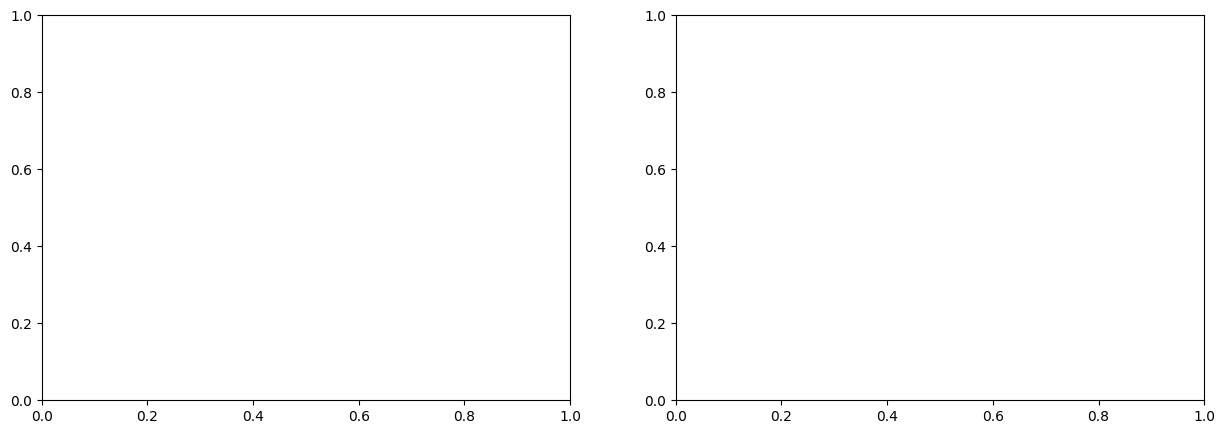

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

In [96]:
sns.boxplot(data=df, x='attack_type', y='bytes_sent', ax=axes[0]) 
axes[0].set_title('Distribución de Bytes Enviados por Ataque')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')

In [97]:
sns.boxplot(data=df, x='attack_type', y='bytes_received', ax=axes[1])
axes[1].set_title('Distribución de Bytes Recibidos por Ataque')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_yscale('log')

In [98]:
plt.tight_layout()
plt.savefig('graficos/boxplot_bytes.png', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

# ### Gráfico 3: Mapa de calor de protocolos y ataques

In [104]:
protocol_attack = pd.crosstab(df['protocol'], df['attack_type'])

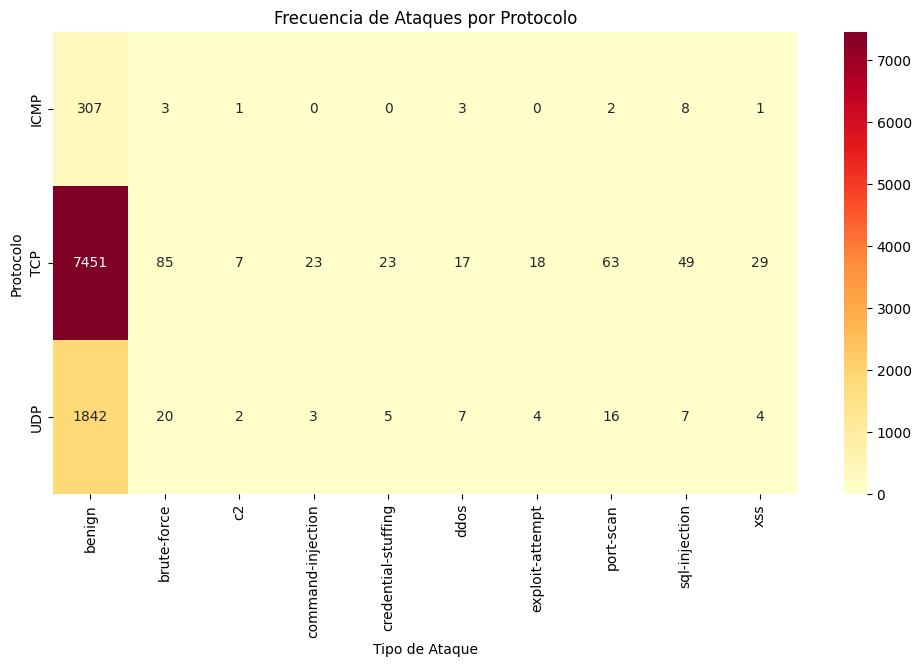

In [105]:
plt.figure(figsize=(12, 6))
sns.heatmap(protocol_attack, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Frecuencia de Ataques por Protocolo')
plt.ylabel('Protocolo')
plt.xlabel('Tipo de Ataque')
plt.savefig('graficos/heatmap_protocolo_ataque.png', dpi=300)
plt.show()

# Gráfico de burbujas interactivo

In [106]:
fig = px.scatter(
    df,
    x='bytes_sent',
    y='bytes_received',
    size='bytes_sent',  # Tamaño según bytes
    color='attack_type',
    hover_name='attack_type',
    log_x=True,
    log_y=True,
    animation_frame='hora' if 'hora' in df.columns else None,
    title='🚀 Tráfico de Red: Bytes Enviados vs Recibidos',
    labels={'bytes_sent': 'Bytes Enviados', 'bytes_received': 'Bytes Recibidos'},
    template='plotly_dark'  # Fondo oscuro elegante
)

In [107]:
fig = px.scatter(
    df,
    x='bytes_sent',
    y='bytes_received',
    size='bytes_sent',  # Tamaño según bytes
    color='attack_type',
    hover_name='attack_type',
    log_x=True,
    log_y=True,
    animation_frame='hora' if 'hora' in df.columns else None,
    title='🚀 Tráfico de Red: Bytes Enviados vs Recibidos',
    labels={'bytes_sent': 'Bytes Enviados', 'bytes_received': 'Bytes Recibidos'},
    template='plotly_dark'  # Fondo oscuro elegante
)

In [108]:
fig.show()

Gráfico de Red (Network Graph)

In [110]:
import networkx as nx

ModuleNotFoundError: No module named 'networkx'